<a href="https://colab.research.google.com/github/ncskr2003/2026_tues-bigdatacomputing_class_20220767/blob/main/20220767_%EC%9E%A5%ED%98%84%EC%84%9C_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  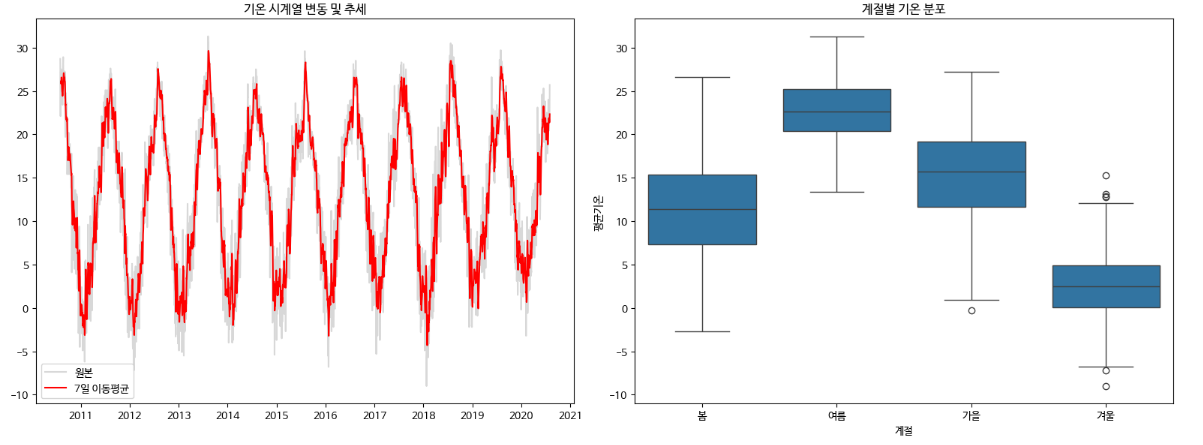

  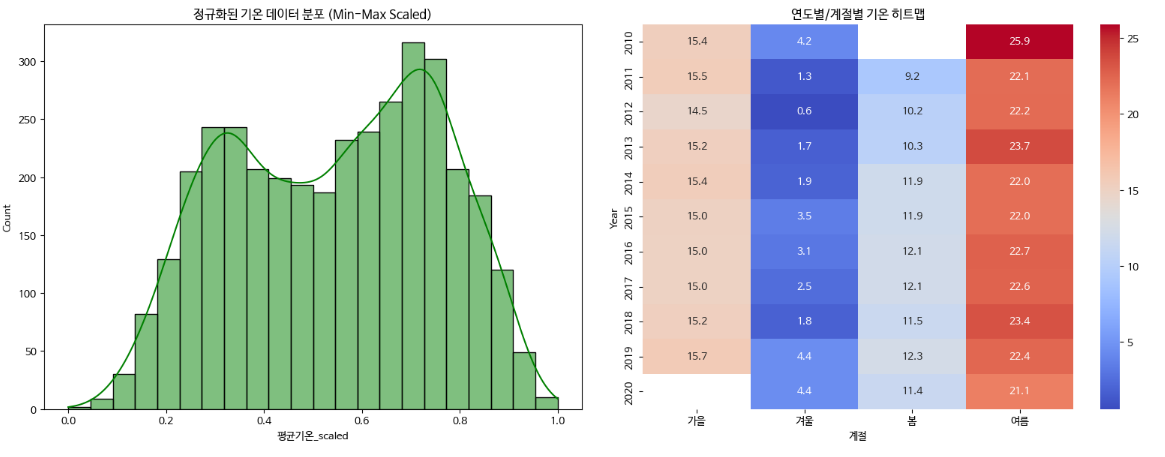



In [82]:
%%writefile setup_korean_font.py
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.font_manager as fm
import pandas as pd

def setup_korean_font():
    """한글 폰트 설정 (수정 버전)"""
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

    # 1. 폰트 파일 존재 여부 확인 및 설치
    if not os.path.exists(font_path):
        print("Installing Nanum fonts...")
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 폰트 추가 (문제의 원인 해결)
    # FontProperties 대신 font_manager.fontManager.addfont를 사용.
    fm.fontManager.addfont(font_path)

    # 3. 전역 설정 적용
    # 'NanumBarunGothic'은 나눔폰트 파일의 실제 이름입니다.
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 한글 폰트 설정 완료 (Matplotlib 연동 성공)")

Overwriting setup_korean_font.py


In [83]:
%run setup_korean_font.py

<Figure size 640x480 with 0 Axes>

In [84]:
from setup_korean_font import setup_korean_font

setup_korean_font()

✅ 한글 폰트 설정 완료 (Matplotlib 연동 성공)


weather_analysis_report.xlsx 저장 완료


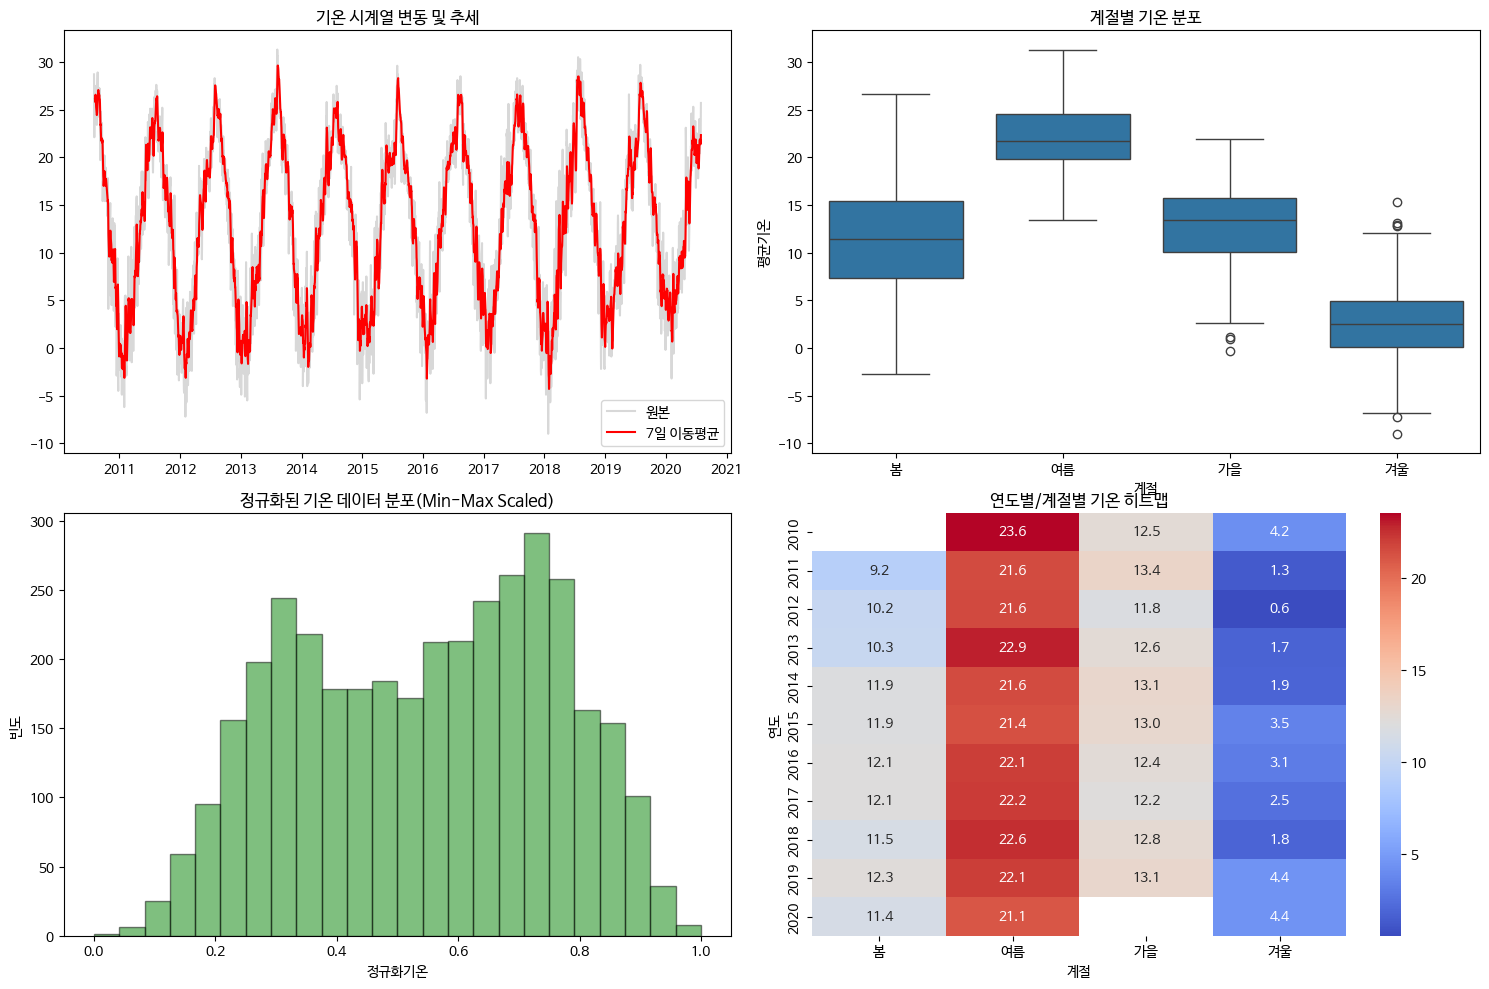

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. 데이터 불러오기
def load_data(file_path):
    df = pd.read_csv(file_path, encoding='cp949')
    return df


# 2. 데이터 정규화 (Min-Max Scaling) 함수
def min_max_scaling(series):
    return (series - series.min()) / (series.max() - series.min())


# 3. 계절 생성 함수 3~5월 = 봄 / 6~9월 = 여름 / 10~11 = 가을 / 12~2월 = 겨울로 지정했습니다
def add_season(df):
    season = {
        1:'겨울', 2:'겨울',
        3:'봄', 4:'봄', 5:'봄',
        6:'여름', 7:'여름', 8:'여름', 9:'여름',
        10:'가을', 11:'가을',
        12:'겨울'
    }

    df['계절'] = df['일시'].dt.month.map(season)
    return df


# 4. 전처리 함수
def preprocess_data(df):
    df['일시'] = pd.to_datetime(df['일시'])

    df['연도'] = df['일시'].dt.year
    df['월'] = df['일시'].dt.month

    df = add_season(df)

    df['7일이동평균'] = df['평균기온'].rolling(window=7).mean()
    df['정규화기온'] = min_max_scaling(df['평균기온'])

    df = df.set_index('일시')

    return df


# 5. groupby 계절별 통계
def create_season_statistics(df):
    season_stat = df.groupby('계절')[['평균기온', '최대풍속', '평균풍속']].agg(['mean', 'max', 'min'])
    return season_stat


# 6. pivot_table 연도별/계절별 평균기온
def create_year_season_pivot(df):
    pivot = df.pivot_table(
        index='연도',
        columns='계절',
        values='평균기온',
        aggfunc='mean'
    )

    pivot = pivot[['봄', '여름', '가을', '겨울']]
    return pivot


# 7. 시계열 그래프
def plot_time_series(df):
    plt.plot(df.index, df['평균기온'], color='gray', alpha=0.3, label='원본')
    plt.plot(df.index, df['7일이동평균'], color='red', label='7일 이동평균')
    plt.legend()
    plt.title('기온 시계열 변동 및 추세')


# 8. 계절별 boxplot
def plot_season_boxplot(df):
    sns.boxplot(
        data=df,
        x='계절',
        y='평균기온',
        order=['봄', '여름', '가을', '겨울']
    )

    plt.xlabel('계절')
    plt.ylabel('평균기온')
    plt.title('계절별 기온 분포')


# 9. 정규화 데이터 히스토그램
def plot_scaled_temperature(df):
    plt.hist(df['정규화기온'], bins=24, color='green', alpha=0.5, edgecolor='black')

    plt.xlabel('정규화기온')
    plt.ylabel('빈도')
    plt.title('정규화된 기온 데이터 분포(Min-Max Scaled)')
    plt.tight_layout()


# 10. 히트맵
def plot_heatmap(pivot):
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='coolwarm')

    plt.title('연도별/계절별 기온 히트맵')
    plt.xlabel('계절')
    plt.ylabel('연도')


# 11. 엑셀 저장
def export_to_excel(df, season_stat, pivot):
    with pd.ExcelWriter('weather_analysis_report.xlsx') as writer:
        df.to_excel(writer, sheet_name='전처리데이터')
        season_stat.to_excel(writer, sheet_name='계절별통계')
        pivot.to_excel(writer, sheet_name='연도별피벗테이블')

    print('weather_analysis_report.xlsx 저장 완료')


# 12. main 함수
def main():
    df = load_data('weather.csv')

    df = preprocess_data(df)

    season_stat = create_season_statistics(df)
    pivot = create_year_season_pivot(df)

    plt.figure(figsize = (15,10))

    plt.subplot(2,2,1)
    plot_time_series(df)
    plt.subplot(2,2,2)
    plot_season_boxplot(df)
    plt.subplot(2,2,3)
    plot_scaled_temperature(df)
    plt.subplot(2,2,4)
    plot_heatmap(pivot)

    export_to_excel(df, season_stat, pivot)


main()